# BTC Regime Discovery -- Gaussian Hidden Markov Model

## Overview

This notebook is **Phase 1** of the BTC regime classifier. Its sole job is to assign a statistically grounded regime label to every day in the BTC price history -- labels that describe the *character* of the market on that day: Bull, Recovery/Chop, Bear, or Extreme Bear.

Rather than hard-coding thresholds ('bear = price down 20%'), a **Gaussian Hidden Markov Model (HMM)** discovers the regime structure directly from the data. No regime definition is imposed -- the model finds the partition of days that minimises prediction error across return, volatility, and drawdown simultaneously.

**Two label series are produced, and both are needed:**

| Column | Algorithm | Uses future data? | When to use |
|--------|-----------|------------------|-------------|
| `regime` | Viterbi -- globally optimal over the *full* history | Yes | Training target for notebook 2's supervised classifier |
| `regime_online` | Forward filter -- uses only data up to each day | No | Feature input for notebook 2; the only version safe for live trading |

The distinction matters: the Viterbi algorithm knows whether today's drawdown eventually recovered or deepened further. The forward filter does not. Viterbi labels are therefore smoother and more accurate -- which is exactly why they make better training targets. But they cannot be computed in real time without introducing lookahead bias into every downstream model trained on them.

**Pipeline:**
1. Construct three features: log return, 5-day realised volatility, 20-day drawdown
2. Select number of states K via BIC (tested K = 2, 3, 4)
3. Fit 4-state GaussianHMM with 5 random restarts
4. Decode Viterbi state sequence; relabel states by mean return
5. Compute causal forward-filter sequence (`regime_online`)
6. Validate economically: do labels align with known market events?
7. Save to `data/labels/btc_regimes.parquet`

**Output feeds into:** `notebooks/2_regime_prediction.ipynb`

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from hmmlearn.hmm import GaussianHMM

REPO       = Path('../../..').resolve()
CACHE_DIR  = REPO / 'live_trading' / 'cache' / 'daily'
LABELS_DIR = REPO / 'topics' / 'regime-classifier' / 'data' / 'labels'
LABELS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
print('Repo:', REPO)

Repo: C:\Users\user\Documents\Epsilon Fund\Epsilon-Quant-Research


---
## 1. Load BTC Data

Daily OHLCV is loaded from the shared Binance cache. The HMM requires only the **Close price** -- all three input features are derived from it. No external data sources or on-chain metrics are used: the regime structure should be derivable from price alone, making the model portable and forward-applicable without additional data pipelines.

The full available history is used (not a fixed lookback) so the model sees as many complete regime cycles as possible. More regime transitions in the training data = better-defined state emission distributions = more stable and interpretable labels.

In [2]:
btc = pd.read_parquet(CACHE_DIR / 'BTCUSDT_daily.parquet')
btc.index = pd.to_datetime(btc.index).tz_localize(None)
btc = btc.sort_index()

print(f'BTC data: {btc.index[0].date()} → {btc.index[-1].date()}  ({len(btc)} rows)')
btc[['Close']].tail(3)

BTC data: 2020-06-05 → 2026-05-08  (2164 rows)


,Close
Time,
2026-05-06,81447.01
2026-05-07,80006.00
2026-05-08,79845.18


---
## 2. Feature Engineering

Three features are used to characterise each day's market state. The design philosophy: use the *minimum* number of features that clearly separate the regimes. More features add noise and make the Gaussian clusters harder to distinguish.

| Feature | Formula | What it captures |
|---------|---------|------------------|
| `log_ret` | $\log(P_t / P_{t-1})$ | Daily return -- direction and magnitude of price move |
| `rvol_5d` | $\text{std}(\log\_ret_{t-4:t})$ | Short-term realised volatility -- how turbulent the market is *right now* |
| `drawdown` | $(P_t - \max(P_{t-59:t})) / \max(P_{t-59:t})$ | Distance below 60-day peak -- how far the market is from its recent high |

**Why log returns and not raw price changes?** Log returns are additive across time, stabilise variance, and make the Gaussian emission assumption more defensible. Raw price changes are proportionally larger at higher price levels -- a 500 USD move at BTC = 5,000 is not statistically equivalent to the same move at BTC = 50,000.

**Why a 5-day vol window?** Short enough to be responsive to regime changes (a bear market starts with a sharp vol spike), long enough to smooth single-day outliers. A 20-day vol window would lag too much at detecting the onset of a new regime.

**Why a 60-day drawdown?** 20-day drawdown resets too quickly in bear markets (a brief relief rally would show drawdown near zero even in the middle of a crash). 60 days captures the sustained depth of a bear regime without being so long that it still shows 2022-level drawdowns in mid-2023.

**Why not include volume, RSI, or Bollinger bands?** More features add parameters to the covariance matrices without adding signal. With only 3 features and 4 states, each Gaussian covariance is a 3x3 matrix (6 unique parameters). Adding 5 more features would make it 8x8 (36 parameters) -- much harder to estimate reliably on ~2,000 data points, and prone to overfitting subtle artefacts in the training data.

All features are **standardised** (zero mean, unit variance) before fitting. Without standardisation, the drawdown feature (values typically -0.5 to 0) would be dwarfed by rvol_5d, and the EM algorithm would effectively ignore it. Standardisation ensures all three features contribute equally to the likelihood computation.

In [3]:
close    = btc['Close']
log_ret  = np.log(close / close.shift(1))
rvol_5d  = log_ret.rolling(5).std()
roll_max = close.rolling(60).max()
drawdown = (close - roll_max) / roll_max  # 0 = at peak, -0.5 = 50% below peak

features = pd.DataFrame({
    'log_ret':  log_ret,
    'rvol_5d':  rvol_5d,
    'drawdown': drawdown,
}, index=close.index).dropna()

# Standardise
feat_mean = features.mean()
feat_std  = features.std()
X         = ((features - feat_mean) / feat_std).values

print(f'Feature matrix: {X.shape[0]} rows × {X.shape[1]} features')
print(f'Date range: {features.index[0].date()} → {features.index[-1].date()}')
features.describe().round(4)

Feature matrix: 2105 rows × 3 features
Date range: 2020-08-03 → 2026-05-08


,log_ret,rvol_5d,drawdown
count,2105.0000,2105.0000,2105.0000
mean,0.0009,0.0263,-0.1197
std,0.0304,0.0155,0.1120
min,-0.1670,0.0026,-0.5413
25%,-0.0131,0.0150,-0.1804
50%,0.0003,0.0231,-0.0908
75%,0.0148,0.0331,-0.0280
max,0.1784,0.0976,0.0000


---
## 3. BIC Model Selection -- How Many Regimes?

The number of states K is not assumed -- it is chosen by fitting models for K = 2, 3, 4 and selecting the K that minimises the **Bayesian Information Criterion**:

$$\text{BIC} = -2 \cdot \mathcal{L} + k \cdot \log(n)$$

where $\mathcal{L}$ is the model log-likelihood (higher = better fit), $k$ is the number of free parameters (more = penalised), and $n$ is the number of observations.

**Why BIC and not AIC?** AIC uses a weaker penalty of $2k$ instead of $k \log(n)$. With $n \approx 2000$ observations, $\log(n) \approx 7.6$, so BIC penalises complexity roughly 3.8x more aggressively. AIC tends to overfit by selecting more states than are truly distinct. BIC is more conservative and selects the parsimonious model.

**Free parameter count** for a K-state Gaussian HMM with d = 3 features:

| Component | Parameters |
|-----------|------------|
| Transition matrix | $K(K-1)$ -- each row sums to 1 |
| Initial state distribution | $K - 1$ |
| State means | $K \times d$ |
| Full covariance matrices | $K \times d(d+1)/2$ |

For K = 4, d = 3: 12 + 3 + 12 + 24 = 51 free parameters.

**5 random restarts per K:** EM (Expectation-Maximisation, the algorithm that fits the HMM) is a local optimisation method -- it is guaranteed to find *a* local optimum but not necessarily the global one. Running 5 restarts with different random seeds and keeping the highest log-likelihood result guards against getting stuck in a poor local solution.

  n=2  log-likelihood=-15133979.5  BIC=30268119.6
  n=3  log-likelihood=-13305007.1  BIC=26610282.1


Model is not converging.  Current: -5751.348528869116 is not greater than -5751.348523657143. Delta is -5.211973075347487e-06
Model is not converging.  Current: -5751.348522111821 is not greater than -5751.348521401467. Delta is -7.103535608621314e-07
Model is not converging.  Current: -5751.34852305957 is not greater than -5751.34852079271. Delta is -2.2668600649922155e-06


  n=4  log-likelihood=-12106588.7  BIC=24213567.6

→ BIC selects 4 states


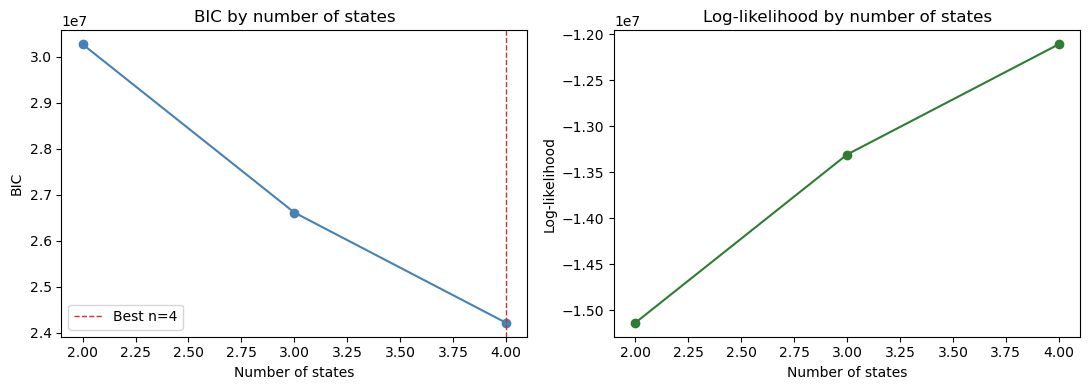

In [4]:
def fit_hmm(X, n_states, n_restarts=5, random_state=42):
    best_model, best_score = None, -np.inf
    for i in range(n_restarts):
        m = GaussianHMM(
            n_components=n_states,
            covariance_type='full',
            n_iter=2000,
            tol=1e-5,
            random_state=random_state + i,
        )
        m.fit(X)
        s = m.score(X)
        if s > best_score:
            best_score, best_model = s, m
    return best_model, best_score


def bic(model, X):
    n, d   = X.shape
    N      = model.n_components
    k      = N*(N-1) + (N-1) + N*d + N*d*(d+1)//2
    return -2 * model.score(X) * n + k * np.log(n)


results = {}
for n in range(2, 5):
    model, score = fit_hmm(X, n, random_state=RANDOM_STATE)
    b = bic(model, X)
    results[n] = {'model': model, 'log_likelihood': score * len(X), 'bic': b}
    print(f'  n={n}  log-likelihood={score*len(X):>10.1f}  BIC={b:>10.1f}')

best_n = min(results, key=lambda n: results[n]['bic'])
print(f'\n→ BIC selects {best_n} states')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ns = list(results.keys())
axes[0].plot(ns, [results[n]['bic'] for n in ns], 'o-', color='steelblue')
axes[0].axvline(best_n, color='#d32f2f', linestyle='--', linewidth=1, label=f'Best n={best_n}')
axes[0].set_xlabel('Number of states'); axes[0].set_ylabel('BIC'); axes[0].set_title('BIC by number of states')
axes[0].legend()
axes[1].plot(ns, [results[n]['log_likelihood'] for n in ns], 'o-', color='#2e7d32')
axes[1].set_xlabel('Number of states'); axes[1].set_ylabel('Log-likelihood'); axes[1].set_title('Log-likelihood by number of states')
plt.tight_layout(); plt.show()

---
## 4. Decode Regime Sequences

Two fundamentally different decoding methods are applied to the same fitted model, producing two label series with different properties.

---

### Method 1: Viterbi Algorithm -> `regime`

The Viterbi algorithm finds the **single globally optimal state sequence** $s_1^*, s_2^*, \ldots, s_T^*$ that maximises the joint probability of the observed data *and* the state assignments:

$$s_1^*, \ldots, s_T^* = \arg\max_{s_1,\ldots,s_T} P(o_1, \ldots, o_T, s_1, \ldots, s_T \mid \theta)$$

It works via dynamic programming: it computes forward probabilities (given observations up to t) **and** backward probabilities (given observations from t to T), then combines them to find the joint optimum. This means **every day's label uses the full time series, including future data**.

Consequence: the label on a given day is retrospectively optimal. A drawdown in October 2021 that quickly recovered is labelled differently from one that deepened into 2022 -- because the Viterbi decoder knows which one it was. This makes it an excellent, smooth training target for the supervised model in notebook 2, but it **cannot be computed in real time without lookahead**.

---

### Method 2: Forward Filter -> `regime_online`

The forward filter computes the probability of being in each state using **only observations up to and including today** -- no future data. The forward probabilities $\alpha_t(k)$ are defined recursively:

**Initialisation:**
$$\alpha_1(k) = \pi_k \cdot B_k(o_1)$$

**Recursion (for each day t):**
$$\alpha_t(k) = B_k(o_t) \cdot \sum_{j=1}^{K} \alpha_{t-1}(j) \cdot A_{jk}$$

where $\pi_k$ = initial state probability, $B_k(o_t)$ = emission probability of observation $o_t$ under state $k$'s Gaussian, and $A_{jk}$ = transition probability from state $j$ to $k$.

The hard label at each time step is $\text{regime\_online}_t = \arg\max_k \, \alpha_t(k)$.

This is **fully causal and safe for live trading**. It is noisier than Viterbi near regime transitions (it lacks the backward smoothing pass) but never peeks at future data. In notebook 2, `regime_online` and its one-day lag are used as features -- representing what the model *would have known* about the current regime in real time.

---

### State Relabelling

After fitting, the HMM's state indices (0, 1, 2, 3) have no inherent economic meaning -- they are assigned arbitrarily by the EM algorithm. To make labels interpretable and consistent across model refits, states are **renumbered by mean return descending**: the state with the highest mean log return becomes state 0 (Bull), the lowest becomes state 3 (Extreme Bear).

Without this step, re-running the notebook could swap the Bull and Bear labels -- which would flip the sign of the filter applied to all downstream strategies.

In [5]:
model = results[best_n]['model']

# Viterbi decode
raw_states = model.predict(X)

# Smoothed probabilities (forward-backward)
smooth_probs = model.predict_proba(X)   # shape (n_days, n_states)

# Relabel states by mean return (descending): 0 = highest return = bull
state_means  = model.means_[:, 0]       # means of log_ret (first feature, standardised)
rank_order   = np.argsort(state_means)[::-1]   # indices sorted high→low mean return
remap        = {old: new for new, old in enumerate(rank_order)}
states       = np.array([remap[s] for s in raw_states])
smooth_probs = smooth_probs[:, rank_order]     # reorder columns to match new labels

# Attach to feature index
regime_df = pd.DataFrame(
    smooth_probs,
    index=features.index,
    columns=[f'p_regime_{i}' for i in range(best_n)]
)
regime_df['regime']  = states
regime_df['log_ret'] = features['log_ret'].values
regime_df['rvol_5d'] = features['rvol_5d'].values
regime_df['drawdown']= features['drawdown'].values

print(f'Regime value counts:')
print(regime_df['regime'].value_counts().sort_index())

Regime value counts:
regime
0    588
1    586
2    475
3    456
Name: count, dtype: int64


---
## 5. Regime Characterisation

Compute key statistics for each regime. This is the primary **economic validation** -- the HMM had no knowledge of what 'bull market' or 'bear market' means. It only saw standardised numbers. If the discovered states align with recognisable market conditions, the model has found genuine structure in the data rather than noise.

**What to expect from a well-specified model:**

| Metric | Bull (0) | Chop (1) | Bear (2) | Extreme Bear (3) |
|--------|----------|----------|----------|------------------|
| Ann. return | Clearly positive (>50%) | Near zero | Negative | Strongly negative |
| Ann. vol | Lowest | Moderate | Elevated | Highest |
| Avg drawdown | Near 0% | Modest (-5% to -10%) | Deep (-15% to -25%) | Very deep (>-25%) |
| Sharpe | Highest | Near zero | Negative | Most negative |

If these orderings are not monotonic (e.g. Bear has lower vol than Chop), the number of states may be wrong or the features need revisiting.

**Time allocation:** Ideally each state covers 20-30% of days. A state covering less than 10% of days is under-represented in the training data and its Gaussian distribution will be estimated with high uncertainty. A state covering more than 50% of days is too broad and probably contains sub-regimes that could be split.

=== Regime Statistics ===
                label  days  pct_time  ann_ret  ann_vol  sharpe  avg_drawdown
regime                                                                       
0                Bull   588      27.9    306.9     50.2    6.12          -1.2
1       Recovery/Chop   586      27.8    -17.5     37.7   -0.46          -7.3
2                Bear   475      22.6   -109.5     44.3   -2.47         -17.5
3        Extreme Bear   456      21.7   -101.1     90.0   -1.12         -26.1


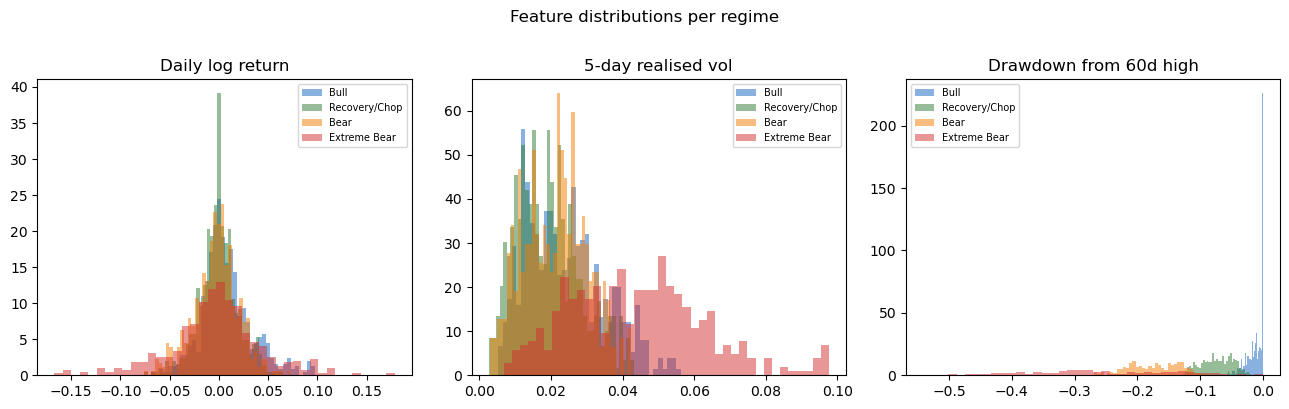

In [6]:
REGIME_COLORS = ['#1565c0', '#2e7d32', '#f57c00', '#d32f2f', '#6a1b9a']
REGIME_NAMES  = ['Bull', 'Recovery/Chop', 'Bear', 'Extreme Bear', 'Extreme Bull']

print('=== Regime Statistics ===')
rows = []
for r in sorted(regime_df['regime'].unique()):
    sub = regime_df[regime_df['regime'] == r]
    ann_ret  = sub['log_ret'].mean() * 365
    ann_vol  = sub['log_ret'].std()  * np.sqrt(365)
    sharpe   = ann_ret / ann_vol if ann_vol > 0 else 0
    avg_dd   = sub['drawdown'].mean()
    pct_time = len(sub) / len(regime_df) * 100
    label    = REGIME_NAMES[r] if r < len(REGIME_NAMES) else f'Regime {r}'
    rows.append({
        'regime':       r,
        'label':        label,
        'days':         len(sub),
        'pct_time':     round(pct_time, 1),
        'ann_ret':      round(ann_ret * 100, 1),
        'ann_vol':      round(ann_vol * 100, 1),
        'sharpe':       round(sharpe, 2),
        'avg_drawdown': round(avg_dd * 100, 1),
    })

stats = pd.DataFrame(rows).set_index('regime')
print(stats.to_string())

# Plot regime distributions
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
feat_names = ['log_ret', 'rvol_5d', 'drawdown']
feat_labels = ['Daily log return', '5-day realised vol', 'Drawdown from 60d high']
for ax, feat, label in zip(axes, feat_names, feat_labels):
    for r in sorted(regime_df['regime'].unique()):
        sub  = regime_df[regime_df['regime'] == r][feat]
        name = REGIME_NAMES[r] if r < len(REGIME_NAMES) else f'Regime {r}'
        ax.hist(sub, bins=40, alpha=0.5, color=REGIME_COLORS[r], label=name, density=True)
    ax.set_title(label); ax.legend(fontsize=7)
plt.suptitle('Feature distributions per regime', y=1.01)
plt.tight_layout(); plt.show()

---
## 6. Transition Matrix

The transition matrix $A$ is one of the three parameter sets the HMM learned (along with state means $\mu$ and covariances $\Sigma$). Entry $A_{ij}$ is the probability of transitioning from regime $i$ to regime $j$ on any given day.

**Reading the matrix:**
- **Diagonal $A_{ii}$**: probability of *staying* in the same regime. High diagonal = sticky regime. Low diagonal = transient regime.
- **Off-diagonal $A_{ij}$**: most likely regime to transition into when leaving regime $i$.
- Each row sums to 1.0 by definition.

**Expected duration formula:** The expected number of consecutive days spent in regime $i$ before transitioning out is:

$$\mathbb{E}[\text{duration in regime } i] = \frac{1}{1 - A_{ii}}$$

For example: if $A_{\text{Bull,Bull}} = 0.97$, the expected Bull run is $1/(1-0.97) = 33$ days before transitioning. If $A_{\text{Extreme Bear,Extreme Bear}} = 0.93$, an Extreme Bear episode typically lasts $1/(1-0.93) = 14$ days.

**What good transition structure looks like:**
- Bull and Chop are adjacent in the mean-return ordering and should have high cross-transition probability
- Extreme Bear to Bull in one step should be near zero -- regime transitions typically step through adjacent states
- All diagonal entries should be high (>0.85) -- regimes should be persistent, not single-day fluctuations. If they are low, the model is overfitting noise rather than finding structural regimes.

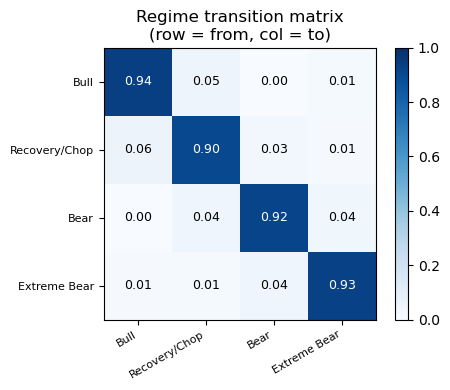

Expected days per regime visit (1 / (1 - p_stay)):
  Bull                  16.2 days avg
  Recovery/Chop         10.2 days avg
  Bear                  12.4 days avg
  Extreme Bear          14.8 days avg


In [7]:
# Reorder transition matrix to match relabelled states
T_raw = model.transmat_
T     = T_raw[np.ix_(rank_order, rank_order)]

n = best_n
labels = [REGIME_NAMES[r] if r < len(REGIME_NAMES) else f'Regime {r}' for r in range(n)]

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(T, cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
ax.set_yticklabels(labels, fontsize=8)
for i in range(n):
    for j in range(n):
        ax.text(j, i, f'{T[i,j]:.2f}', ha='center', va='center',
                fontsize=9, color='white' if T[i,j] > 0.5 else 'black')
ax.set_title('Regime transition matrix\n(row = from, col = to)')
plt.tight_layout(); plt.show()

print('Expected days per regime visit (1 / (1 - p_stay)):')
for i, lbl in enumerate(labels):
    stay = T[i, i]
    print(f'  {lbl:<20s}  {1/(1-stay):.1f} days avg')

---
## 7. Regime Timeline

Plot the full BTC price history with regime colour shading. Three panels:
- **Top**: BTC price (log scale) with coloured regime bands
- **Middle**: Drawdown from 60-day high -- should correlate with Bear/Extreme Bear shading
- **Bottom**: 5-day realised vol -- should spike during Bear/Extreme Bear regimes

This is the primary visual validation. The HMM had no knowledge of calendar events -- if the coloured bands align with known market episodes, the model has independently discovered the correct structure.

**Reference events to verify:**

| Period | Expected regime | BTC price action |
|--------|----------------|------------------|
| Aug--Oct 2020 | Bull | 12k --> 14k, initial breakout |
| Nov 2020 -- Apr 2021 | Bull | 14k --> 65k, strong uptrend |
| May -- Jul 2021 | Bear | 65k --> 29k, sharp correction |
| Aug -- Oct 2021 | Bull | 29k --> 69k, recovery and new ATH |
| Nov 2021 -- Jun 2022 | Bear then Extreme Bear | 69k --> 17k, full bear market |
| Nov 2022 (FTX collapse) | Extreme Bear | Sudden drop to ~15k |
| 2023 | Chop then Bull | Slow grind from 16k to 45k |
| Jan 2024 (ETF approval) | Bull | 45k --> 73k |
| May -- Sep 2024 | Chop | 73k --> 55k, choppy consolidation |

If Bear regime shading appears on Bull run days, or Bull shading appears during the 2022 crash, the model needs re-examination.

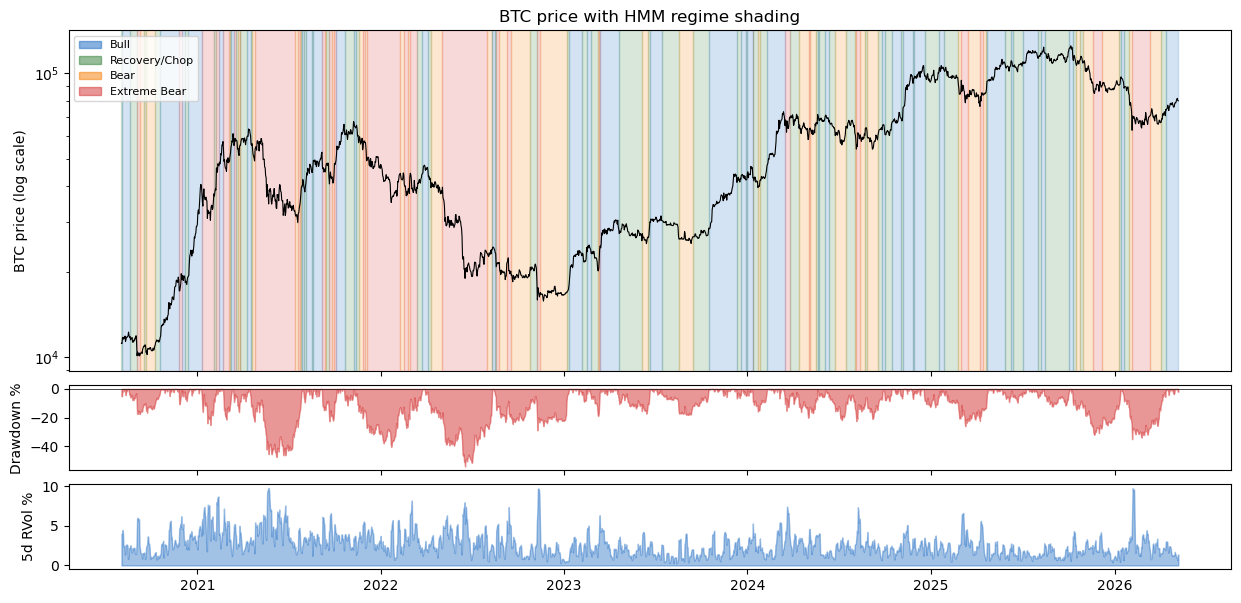

In [8]:
price_aligned = close.reindex(regime_df.index)

fig = plt.figure(figsize=(15, 7))
gs  = gridspec.GridSpec(3, 1, height_ratios=[4, 1, 1], hspace=0.08)

ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1], sharex=ax0)
ax2 = fig.add_subplot(gs[2], sharex=ax0)

# Price + regime shading
ax0.semilogy(price_aligned.index, price_aligned.values, color='black', linewidth=0.8, zorder=3)
prev_r, prev_date = regime_df['regime'].iloc[0], regime_df.index[0]
for i in range(1, len(regime_df)):
    r = regime_df['regime'].iloc[i]
    if r != prev_r or i == len(regime_df) - 1:
        ax0.axvspan(prev_date, regime_df.index[i],
                    color=REGIME_COLORS[prev_r], alpha=0.18, zorder=1)
        prev_r, prev_date = r, regime_df.index[i]

# Legend patches
from matplotlib.patches import Patch
legend_els = [Patch(color=REGIME_COLORS[r], alpha=0.5,
                    label=REGIME_NAMES[r] if r < len(REGIME_NAMES) else f'Regime {r}')
              for r in sorted(regime_df['regime'].unique())]
ax0.legend(handles=legend_els, fontsize=8, loc='upper left')
ax0.set_ylabel('BTC price (log scale)')
ax0.set_title('BTC price with HMM regime shading')
plt.setp(ax0.get_xticklabels(), visible=False)

# Drawdown
ax1.fill_between(regime_df.index, regime_df['drawdown'] * 100, 0,
                 color='#d32f2f', alpha=0.5)
ax1.set_ylabel('Drawdown %')
ax1.axhline(0, color='black', linewidth=0.5)
plt.setp(ax1.get_xticklabels(), visible=False)

# Realised vol
ax2.fill_between(regime_df.index, regime_df['rvol_5d'] * 100, 0,
                 color='#1565c0', alpha=0.4)
ax2.set_ylabel('5d RVol %')

plt.show()

---
## 8. Smoothed Probability Time Series

The Viterbi algorithm produces one hard label per day. The **forward-backward algorithm** (used separately via `predict_proba`) produces a full probability distribution over all four states for each day -- this is the 'soft' view of regime assignment.

**How to read the stacked area chart:**
- **Wide, single-colour bands** = the model is highly confident (one state probability near 1.0). This is typical of mid-regime periods -- well into a sustained bull run or deep into a bear market.
- **Thin, mixed-colour sections** = regime uncertainty. Multiple states have meaningful probability. This typically occurs at transition points: the 2-3 days around a regime shift where the model is genuinely uncertain whether the new regime has started.
- **Frequent alternation between two states** = possible over-specification (too many states). If you see rapid Bull/Chop switching every 2-3 days, consider reducing K.

**What is saved vs what is used:**
- The smoothed probabilities (`p_regime_0` through `p_regime_3`) are saved to the parquet for reference and analysis.
- The hard Viterbi `regime` column is the **training target** for notebook 2's XGBoost classifier -- not the probabilities.
- The causal `regime_online` is the **feature** used in notebook 2 -- not the smoothed probabilities (which also use future data).

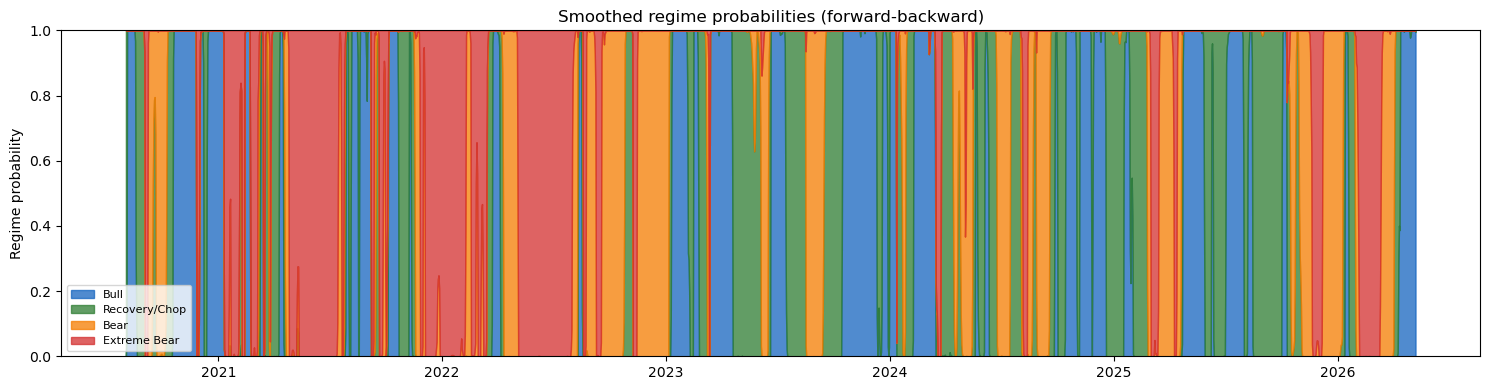

In [9]:
prob_cols = [c for c in regime_df.columns if c.startswith('p_regime_')]

fig, ax = plt.subplots(figsize=(15, 4))
bottom = np.zeros(len(regime_df))
for i, col in enumerate(prob_cols):
    label = REGIME_NAMES[i] if i < len(REGIME_NAMES) else f'Regime {i}'
    ax.fill_between(regime_df.index, bottom, bottom + regime_df[col].values,
                    color=REGIME_COLORS[i], alpha=0.75, label=label)
    bottom += regime_df[col].values
ax.set_ylim(0, 1)
ax.set_ylabel('Regime probability')
ax.set_title('Smoothed regime probabilities (forward-backward)')
ax.legend(fontsize=8, loc='lower left')
plt.tight_layout(); plt.show()

---
## 9. Drawdown Validation

A critical sanity check. The HMM was not told what a drawdown is -- drawdown is just one of three equal input features. If the model independently produces Bear/Extreme Bear labels on days with deep drawdowns, it confirms the model has discovered genuine economic structure rather than over-indexing on one feature.

**Three validation metrics are reported:**

1. **Average drawdown per regime:** Should be monotonically decreasing from Bull (~0%) to Extreme Bear (~-25%). Non-monotonic ordering would suggest the Bear and Extreme Bear states are not well-separated.

2. **Fraction of deep-drawdown days (>20%) per regime:** Should be near 0% for Bull and Chop, 20-40% for Bear, and 50-70% for Extreme Bear. This tests whether the Extreme Bear label is genuinely reserved for the worst conditions.

3. **Correlation of regime dummy with drawdown:** Bull should have strong *positive* correlation with drawdown (bull days = near-zero drawdown = near zero = positive), while Bear and Extreme Bear should have strong *negative* correlation. The magnitude of correlation for Extreme Bear should exceed that of Bear.

If these checks pass, the regime labels are trustworthy. The validation confirms the labels are economically meaningful without any circular dependency on imposed thresholds.

In [10]:
print('=== Drawdown validation ===')
print('Average drawdown from 60-day high per regime:')
dd_by_regime = regime_df.groupby('regime')['drawdown'].mean() * 100
for r, dd in dd_by_regime.sort_values().items():
    label = REGIME_NAMES[r] if r < len(REGIME_NAMES) else f'Regime {r}'
    bar = '█' * int(abs(dd) / 2)
    print(f'  Regime {r} ({label:<20s})  {dd:>6.1f}%  {bar}')

print('\nFraction of days with drawdown > 20%:')
for r in sorted(regime_df['regime'].unique()):
    sub   = regime_df[regime_df['regime'] == r]
    label = REGIME_NAMES[r] if r < len(REGIME_NAMES) else f'Regime {r}'
    frac  = (sub['drawdown'] < -0.20).mean() * 100
    print(f'  Regime {r} ({label:<20s})  {frac:.1f}%')

# Correlation of regime dummy with drawdown depth
print('\nCorrelation of regime dummy with drawdown:')
for r in sorted(regime_df['regime'].unique()):
    label = REGIME_NAMES[r] if r < len(REGIME_NAMES) else f'Regime {r}'
    dummy = (regime_df['regime'] == r).astype(float)
    corr  = dummy.corr(regime_df['drawdown'])
    print(f'  Regime {r} ({label:<20s})  r={corr:+.3f}')

=== Drawdown validation ===
Average drawdown from 60-day high per regime:
  Regime 3 (Extreme Bear        )   -26.1%  █████████████
  Regime 2 (Bear                )   -17.5%  ████████
  Regime 1 (Recovery/Chop       )    -7.3%  ███
  Regime 0 (Bull                )    -1.2%  

Fraction of days with drawdown > 20%:
  Regime 0 (Bull                )  0.0%
  Regime 1 (Recovery/Chop       )  0.0%
  Regime 2 (Bear                )  32.0%
  Regime 3 (Extreme Bear        )  65.6%

Correlation of regime dummy with drawdown:
  Regime 0 (Bull                )  r=+0.600
  Regime 1 (Recovery/Chop       )  r=+0.259
  Regime 2 (Bear                )  r=-0.267
  Regime 3 (Extreme Bear        )  r=-0.664


---
## 10. Compute Forward Filter Labels and Save

Before saving, `regime_online` is computed using the **causal forward filter** -- the version of regime assignment that uses only data up to each day. This is architecturally distinct from the smoothed probabilities already in `regime_df`:

| Label | Algorithm | Lookahead | Accuracy |
|-------|-----------|-----------|----------|
| `regime` | Viterbi (forward + backward pass) | Yes -- uses full history | Highest (uses future data) |
| `p_regime_*` | Forward-backward smoothing | Yes -- same as Viterbi | High (soft probabilities) |
| `regime_online` | Forward filter (forward pass only) | **No** | Lower near transitions (no hindsight) |

**Why compute it here rather than in notebook 2?** The forward filter uses the same trained HMM parameters (transition matrix, emission distributions) as the Viterbi decoder. It must be computed on the same model object that produced the Viterbi labels, to guarantee the two label series are based on identical model parameters. Computing it here also means it is saved alongside the Viterbi labels in the parquet, making it available to any downstream notebook.

**Output schema:**

| Column | Description |
|--------|-------------|
| `regime` | Viterbi label: 0 = Bull, 1 = Recovery/Chop, 2 = Bear, 3 = Extreme Bear |
| `regime_online` | Forward-filter label: causal, no lookahead |
| `p_regime_0` -- `p_regime_3` | Smoothed forward-backward probabilities (reference) |
| `log_ret` | Daily BTC log return |
| `rvol_5d` | 5-day realised volatility |
| `drawdown` | Drawdown from 60-day rolling high |

In [11]:
# Forward filter — compute regime_online (causal, no lookahead)
# At each time t, uses only observations 1..t. Safe for live trading.

framelogprob = model._compute_likelihood(X)   # emission log-prob per state
n_samples    = len(framelogprob)
n_states_fit = model.n_components

log_alpha    = np.zeros((n_samples, n_states_fit))
log_alpha[0] = np.log(model.startprob_ + 1e-300) + framelogprob[0]

for t in range(1, n_samples):
    for j in range(n_states_fit):
        log_alpha[t, j] = (
            np.logaddexp.reduce(log_alpha[t-1] + np.log(model.transmat_[:, j] + 1e-300))
            + framelogprob[t, j]
        )

# Normalise each row to get a valid probability distribution
log_norm   = np.logaddexp.reduce(log_alpha, axis=1, keepdims=True)
alpha_norm = np.exp(log_alpha - log_norm)

# Hard label: argmax, then relabel to match the Viterbi ordering (0=Bull)
raw_online          = np.argmax(alpha_norm, axis=1)
regime_online_arr   = np.array([remap[s] for s in raw_online])
regime_df['regime_online'] = regime_online_arr

# Quick comparison: how often do Viterbi and online labels agree?
agree = (regime_df['regime'] == regime_df['regime_online']).mean()
print(f'Viterbi vs online agreement: {agree*100:.1f}%  (lower near transitions is expected)')
print()
print('regime_online distribution:')
print(regime_df['regime_online'].value_counts().sort_index())


Viterbi vs online agreement: 61.6%  (lower near transitions is expected)

regime_online distribution:
regime_online
0    924
1    668
2    471
3     42
Name: count, dtype: int64


In [12]:
out_path = LABELS_DIR / 'btc_regimes.parquet'

# Reorder columns for clarity
col_order = (['p_regime_' + str(i) for i in range(best_n)]
             + ['regime', 'regime_online', 'log_ret', 'rvol_5d', 'drawdown'])
regime_df[col_order].to_parquet(out_path, engine='pyarrow')

print(f'Saved -> {out_path}')
print(f'{len(regime_df)} rows  |  {best_n} regimes  |  {regime_df.index[0].date()} to {regime_df.index[-1].date()}')
print(f'Columns: {col_order}')
regime_df[col_order].tail(3)


Saved -> C:\Users\user\Documents\Epsilon Fund\Epsilon-Quant-Research\topics\regime-classifier\data\labels\btc_regimes.parquet
2105 rows  |  4 regimes  |  2020-08-03 to 2026-05-08
Columns: ['p_regime_0', 'p_regime_1', 'p_regime_2', 'p_regime_3', 'regime', 'regime_online', 'log_ret', 'rvol_5d', 'drawdown']


,p_regime_0,p_regime_1,p_regime_2,p_regime_3,regime,regime_online,log_ret,rvol_5d,drawdown
Time,,,,,,,,,
2026-05-06,0.999934,0.000066,7.047084e-14,4.750485e-08,0,0,0.006671,0.006910,0.000000
2026-05-07,0.999736,0.000264,5.190599e-12,7.944301e-08,0,0,-0.017851,0.013649,-0.017693
2026-05-08,0.994955,0.005036,6.292506e-09,8.131171e-06,0,0,-0.002012,0.013696,-0.019667
